# Secretos estáticos con Vault Secrets Operator y CSI

In [ ]:
%%bash
set -euo pipefail
if ! docker info >/dev/null 2>&1; then
  open -a Docker
  echo 'Esperando a Docker Desktop...'
  for attempt in $(seq 1 90); do
    docker info >/dev/null 2>&1 && break
    [[ "$attempt" -eq 90 ]] && { echo 'Docker Desktop no está listo' >&2; exit 1; }
    sleep 2
  done
fi
docker info --format 'Docker {{.ServerVersion}} listo'

In [1]:
! minikube start -p workshop --force

😄  [workshop] minikube v1.38.1 on Darwin 26.5.2 (arm64)
❗  minikube skips various validations when --force is supplied; this may lead to unexpected behavior
✨  Automatically selected the docker driver. Other choices: vfkit, ssh
❗  Starting v1.39.0, minikube will default to "containerd" container runtime. See #21973 for more info.
📌  Using Docker Desktop driver with root privileges
👍  Starting "workshop" primary control-plane node in "workshop" cluster
🚜  Pulling base image v0.0.50 ...
🔥  Creating docker container (CPUs=2, Memory=7885MB) ...7m|
🐳  Preparing Kubernetes v1.35.1 on Docker 29.2.1 ...7m-
🔗  Configuring bridge CNI (Container Networking Interface) ...
🔎  Verifying Kubernetes components...
    ▪ Using image gcr.io/k8s-minikube/storage-provisioner:v5
🌟  Enabled addons: storage-provisioner, default-storageclass
🏄  Done! kubectl is now configured to use "workshop" cluster and "default" namespace by default


## Instalación vía HELM

In [2]:
%%bash
# Añadir el repositorio de Helm de HashiCorp y actualizar el índice
helm repo add hashicorp https://helm.releases.hashicorp.com
helm repo update

"hashicorp" already exists with the same configuration, skipping
Hang tight while we grab the latest from your chart repositories...
...Successfully got an update from the "secrets-store-csi-driver" chart repository
...Successfully got an update from the "hashicorp" chart repository
...Successfully got an update from the "kspm-helm-charts" chart repository
...Successfully got an update from the "bitnami" chart repository
Update Complete. ⎈Happy Helming!⎈


### Instalación del Vault Secrets Operator (VSO)

Instalamos el Vault Secrets Operator utilizando Helm. Este operador se encargará de gestionar la sincronización de secretos entre Vault y Kubernetes.

In [3]:
%%bash
# Limpiar todos los recursos cluster-scoped huérfanos creados por OLM.
# OLM deja ClusterRoles y ClusterRoleBindings al eliminar la suscripción/CSV.
kubectl get clusterrole,clusterrolebinding \
  --no-headers -o custom-columns='KIND:.kind,NAME:.metadata.name' \
  | awk '/vault|hcpvault/ {print tolower($1) "/" $2}' \
  | xargs -r kubectl delete --ignore-not-found

# Instalar VSO vía Helm usando imágenes de DockerHub (hashicorp/vault-secrets-operator).
# Las imágenes UBI del manager y kube-rbac-proxy en DockerHub/GCR son manifiestos
# multi-arch que incluyen arm64 — no requiere autenticación a Red Hat registry.
# --no-hooks evita los Jobs de pre-install/pre-delete para que 'helm uninstall'
# no se bloquee si la imagen no puede descargarse.
helm upgrade --install vault-secrets-operator hashicorp/vault-secrets-operator \
  --version 1.2.0 \
  --create-namespace \
  --namespace vault-secrets-operator \
  --no-hooks \
  --set csi.enabled=true \
  --set controller.manager.image.repository=hashicorp/vault-secrets-operator \
  --set controller.manager.resources.requests.memory=128Mi \
  --set controller.manager.resources.limits.memory=256Mi

echo "Esperando a que el pod de VSO esté listo..."
kubectl rollout status deployment/vault-secrets-operator-controller-manager \
  -n vault-secrets-operator --timeout=180s

I0728 11:13:19.836042   94890 warnings.go:107] "Warning: spec.serviceAccountTokenInSecrets is unset; if supported by this CSI driver, set to true to prevent possible logging of tokens in volume attributes"


NAME: vault-secrets-operator
LAST DEPLOYED: Tue Jul 28 11:13:19 2026
NAMESPACE: vault-secrets-operator
STATUS: deployed
REVISION: 1
DESCRIPTION: Install complete
Esperando a que el pod de VSO esté listo...
Waiting for deployment "vault-secrets-operator-controller-manager" rollout to finish: 0 of 1 updated replicas are available...
deployment "vault-secrets-operator-controller-manager" successfully rolled out


In [4]:
# Verificar que los pods de VSO están corriendo en su namespace
! kubectl get pods -n vault-secrets-operator

NAME                                                         READY   STATUS    RESTARTS   AGE
vault-secrets-operator-controller-manager-7d8499f575-gnks6   2/2     Running   0          40s
vault-secrets-operator-csi-node-lgbfw                        2/3     Running   0          40s


## Configurar JWT Auth Method

In [5]:
%%bash
# Permitir el acceso no autenticado a los endpoints de descubrimiento OIDC
# (/.well-known/openid-configuration y /openid/v1/jwks).
# Estos endpoints solo exponen claves públicas criptográficas, por lo que
# el riesgo de seguridad es mínimo. Vault necesita acceder a estos endpoints
# para obtener las claves públicas sin autenticarse contra el API server.
kubectl create clusterrolebinding oidc-reviewer \
   --clusterrole=system:service-account-issuer-discovery \
   --group=system:unauthenticated \
   --dry-run=client -o yaml | kubectl apply -f -

clusterrolebinding.rbac.authorization.k8s.io/oidc-reviewer created


In [6]:
%%bash
# Obtener el emisor (issuer) de tokens del clúster desde el endpoint OIDC.
# En OpenShift, típicamente es "https://kubernetes.default.svc".
ISSUER="$(kubectl get --raw /.well-known/openid-configuration | jq -r '.issuer')"
echo $ISSUER

https://kubernetes.default.svc.cluster.local


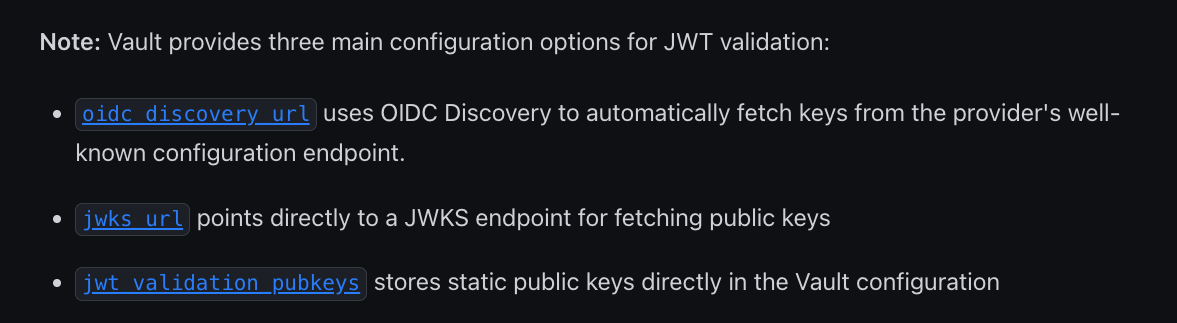

## Obtener clave pública JWKS

In [7]:
%%bash
# Extraer la primera clave pública JWKS del clúster y convertirla de formato JWK a PEM.
# Se usa el módulo crypto de Node.js para la conversión (sin dependencias externas).
kubectl get --raw \
  "$(kubectl get --raw /.well-known/openid-configuration | jq -r '.jwks_uri' | sed 's|https://[^/]*||')" \
| jq '.keys[0]' \
| node -e "const c=require('crypto');let d='';process.stdin.on('data',x=>d+=x).on('end',()=>console.log(c.createPublicKey({key:JSON.parse(d),format:'jwk'}).export({type:'spki',format:'pem'})))"

-----BEGIN PUBLIC KEY-----
MIIBIjANBgkqhkiG9w0BAQEFAAOCAQ8AMIIBCgKCAQEA0OkIuABS3KOao/h73Om3
UApzaWKV6mBuVMKr+HZ1pyD9Fc10RfuCx1zo5ojez0B16N6DrzdMoE5/2CoknSqm
xo6nKmm2IGkCvjRCYNl9SAS262ZQ/ClS0aiSYluqMDYAfhicfoAP/k1hq3Z9jEEM
GtcZw9KjBg/5az6itrOyq11467jhirxwfEmppdlP355xflyxmntpoipZ0i81ebdc
5xHOTLKnM+EnSeuQ6oLaUQ56o19VaKgNQxJ457M84v0dKXWN0MWpaTtBvKk7Lmym
74qaHSDKO8foh8k9LOYXHiW8aMoIVxD/UZNPZcZH5r0t768DNFm+VG3tmcPQLfZu
FwIDAQAB
-----END PUBLIC KEY-----



## Acceder a Vault

In [8]:
%env WORKDIR=/tmp/vault
import os
os.makedirs(os.environ["WORKDIR"], exist_ok=True)

env: WORKDIR=/tmp/vault


In [9]:
import os
from pathlib import Path

ENV_FILE = next((directory / ".env" for directory in (Path.cwd(), *Path.cwd().parents) if (directory / ".env").is_file()), None)
if ENV_FILE is None:
    raise FileNotFoundError("Could not find the persistent .env file")

for line in ENV_FILE.read_text().splitlines():
    line = line.strip()
    if line and not line.startswith("#") and "=" in line:
        key, value = line.split("=", 1)
        os.environ[key.strip()] = value.strip().strip("\"'")

VAULT_TOKEN = os.getenv('VAULT_TOKEN')
VAULT_ADDR = os.getenv('VAULT_ADDR')
VAULT_CACERT = os.getenv('VAULT_CACERT')

## Habilitar autenticación JWT

In [10]:
# Habilitar el método de autenticación JWT en Vault (mount por defecto: jwt/)
! vault auth enable jwt

Success! Enabled jwt auth method at: jwt/


In [11]:
%%bash
set -euo pipefail

# Obtener la ruta JWKS publicada por el API server.
JWKS_PATH=$(
  kubectl get --raw /.well-known/openid-configuration |
    jq -r '.jwks_uri' |
    sed 's|https://[^/]*||'
)

# Convertir todas las claves JWK a PEM y construir un array JSON válido.
PUBKEYS_JSON=$(
  kubectl get --raw "${JWKS_PATH}" |
    node -e '
      const crypto = require("crypto");

      let input = "";
      process.stdin.on("data", chunk => input += chunk);
      process.stdin.on("end", () => {
        const jwks = JSON.parse(input);

        const publicKeys = jwks.keys.map(jwk =>
          crypto.createPublicKey({
            key: jwk,
            format: "jwk"
          }).export({
            type: "spki",
            format: "pem"
          })
        );

        process.stdout.write(JSON.stringify(publicKeys));
      });
    '
)

# Construir el payload con jq para escapar correctamente los PEM.
jq -n \
  --argjson public_keys "${PUBKEYS_JSON}" \
  '{jwt_validation_pubkeys: $public_keys}' |
curl \
  --silent -k \
  --show-error \
  --fail-with-body \
  --request PUT \
  --header "Content-Type: application/json" \
  --header "X-Vault-Token: ${VAULT_TOKEN}" \
  --data-binary @- \
  "${VAULT_ADDR}/v1/auth/jwt/config"

In [12]:
%%bash
# Crear un rol JWT en Vault que mapea la cuenta de servicio de Kubernetes
# a una política de Vault. Solo se aceptan tokens con la audiencia correcta
# y del service account "default" en el namespace "default".
vault write auth/jwt/role/my-role \
  role_type=jwt \
  bound_audiences=vault \
  user_claim=sub \
  bound_subject="system:serviceaccount:default:static-secret-viewer" \
  policies=devk8s \
  ttl=1h

Success! Data written to: auth/jwt/role/my-role


### Política de acceso

In [13]:
%%bash
# Crear un KV v2 y un secreto estático de ejemplo.
vault secrets enable -path=kvv2 kv-v2 2>/dev/null || true
vault kv put kvv2/apps/demo \
  username=demo-user \
  password=change-me \
  api_key=demo-api-key

# La política permite únicamente leer este secreto KV v2.
vault policy write devk8s - <<EOF
path "kvv2/data/apps/demo" {
  capabilities = ["read"]
}
EOF

Success! Enabled the kv-v2 secrets engine at: kvv2/
=== Secret Path ===
kvv2/data/apps/demo

======= Metadata =======
Key                Value
---                -----
created_time       2026-07-28T09:14:13.934895782Z
custom_metadata    <nil>
deletion_time      n/a
destroyed          false
version            1
Success! Uploaded policy: devk8s


### Configurar la conexión de VSO con Vault (VaultConnection)

Creamos un recurso `VaultConnection` que define cómo el operador debe conectarse a la instancia de Vault. En este caso, apuntamos a la dirección de Vault configurada en las variables de entorno.

In [14]:
%%bash
# Crear el recurso VaultConnection que indica a VSO cómo conectarse a Vault.
# Usa la dirección configurada en VAULT_ADDR como destino.
cat > "${WORKDIR}/vso_crd.yaml" <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultConnection
metadata:
  namespace: default
  name: example
spec:
  address: ${VAULT_ADDR}
  # skip TLS verification for TLS connections to Vault.
  skipTLSVerify: true


EOF

kubectl apply -f "${WORKDIR}/vso_crd.yaml"

vaultconnection.secrets.hashicorp.com/example created


In [15]:
# Verificar el estado del recurso VaultConnection
! kubectl describe VaultConnection example -n default

Name:         example
Namespace:    default
Labels:       <none>
Annotations:  <none>
API Version:  secrets.hashicorp.com/v1beta1
Kind:         VaultConnection
Metadata:
  Creation Timestamp:  2026-07-28T09:14:15Z
  Finalizers:
    vaultconnection.secrets.hashicorp.com/finalizer
  Generation:        1
  Resource Version:  645
  UID:               3fb642ec-a236-4f5e-b189-46b8bba1c1e1
Spec:
  Address:         https://vault.jose-merchan.sbx.hashidemos.io
  Skip TLSVerify:  true
Status:
  Conditions:
    Last Transition Time:  2026-07-28T09:14:15Z
    Message:               Vault ping, address=https://vault.jose-merchan.sbx.hashidemos.io
    Observed Generation:   1
    Reason:                Accepted
    Status:                True
    Type:                  VaultPing
    Last Transition Time:  2026-07-28T09:14:15Z
    Message:               Successfully validated resource, address=https://vault.jose-merchan.sbx.hashidemos.io
    Observed Generation:   1
    Reason:                Accepte

### Configurar la autenticación de VSO (VaultAuth)

Creamos un recurso `VaultAuth` que especifica el método de autenticación que VSO utilizará para autenticarse con Vault. Usamos el método `jwt` y el rol `my-role` que configuramos anteriormente. Esto permite que VSO utilice la cuenta de servicio de Kubernetes para obtener un token de Vault.

In [16]:
%%bash
# Crear el recurso VaultAuth que configura la autenticación JWT con Vault.
# Usa una cuenta de servicio dedicada en el mismo namespace que las cargas.
kubectl create serviceaccount static-secret-viewer -n default --dry-run=client -o yaml | kubectl apply -f -

cat > "${WORKDIR}/vaultauth_crd.yaml" <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultAuth
metadata:
  namespace: default
  name: example
spec:
  vaultConnectionRef: example
  method: jwt
  mount: jwt

  jwt:
    role: my-role
    serviceAccount: static-secret-viewer
    audiences: ["vault"]

EOF
kubectl apply -f "${WORKDIR}/vaultauth_crd.yaml"

serviceaccount/static-secret-viewer created
vaultauth.secrets.hashicorp.com/example created


In [17]:
# Verificar el estado del recurso VaultAuth
! kubectl describe VaultAuth example -n default

Name:         example
Namespace:    default
Labels:       <none>
Annotations:  <none>
API Version:  secrets.hashicorp.com/v1beta1
Kind:         VaultAuth
Metadata:
  Creation Timestamp:  2026-07-28T09:14:18Z
  Finalizers:
    vaultauth.secrets.hashicorp.com/finalizer
  Generation:        1
  Resource Version:  653
  UID:               318edb0c-d3df-4132-8b5d-6d2d3d2c1fbd
Spec:
  Jwt:
    Audiences:
      vault
    Role:                      my-role
    Service Account:           static-secret-viewer
    Token Expiration Seconds:  600
  Method:                      jwt
  Mount:                       jwt
  Vault Connection Ref:        example
Status:
  Conditions:
    Last Transition Time:  2026-07-28T09:14:18Z
    Message:               VaultAuthHealthy
    Observed Generation:   1
    Reason:                Healthy
    Status:                True
    Type:                  Healthy
  Spec Hash:               3794371631b353950b05be502658b7cda72ae2c607997268f472ecf88436c41a
  Valid:      

In [18]:
%%bash
# Patrón 1: sincronizar KV v2 a un Secret de Kubernetes.
cat > "${WORKDIR}/vault_static_secret.yaml" <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultStaticSecret
metadata:
  namespace: default
  name: app-static-secret
spec:
  vaultAuthRef: example
  type: kv-v2
  mount: kvv2
  path: apps/demo
  refreshAfter: 1m
  destination:
    create: true
    overwrite: true
    name: app-static-secret
EOF

kubectl apply -f "${WORKDIR}/vault_static_secret.yaml"

vaultstaticsecret.secrets.hashicorp.com/app-static-secret created


In [19]:
# Verificar el estado de sincronización del VaultStaticSecret
! kubectl describe VaultStaticSecret app-static-secret -n default

Name:         app-static-secret
Namespace:    default
Labels:       <none>
Annotations:  <none>
API Version:  secrets.hashicorp.com/v1beta1
Kind:         VaultStaticSecret
Metadata:
  Creation Timestamp:  2026-07-28T09:14:20Z
  Finalizers:
    vaultstaticsecret.secrets.hashicorp.com/finalizer
  Generation:        2
  Resource Version:  663
  UID:               ad69c2d3-74ed-4f88-82f3-c3d063c47645
Spec:
  Destination:
    Create:     true
    Name:       app-static-secret
    Overwrite:  true
    Transformation:
  Hmac Secret Data:  true
  Mount:             kvv2
  Path:              apps/demo
  Refresh After:     1m
  Type:              kv-v2
  Vault Auth Ref:    example
Status:
  Conditions:
    Last Transition Time:  2026-07-28T09:14:20Z
    Message:               Secret synced, horizon=52.715766787s
    Observed Generation:   2
    Reason:                Synced
    Status:                True
    Type:                  SecretSynced
    Last Transition Time:  2026-07-28T09:14:20Z
   

In [20]:
! kubectl get secret app-static-secret -n default

NAME                TYPE     DATA   AGE
app-static-secret   Opaque   4      2s


In [21]:
%%bash
# Mostrar únicamente los nombres de las claves, nunca sus valores.
kubectl get secret app-static-secret -n default -o json | jq -r '.data.api_key, .data.password, .data.username'

ZGVtby1hcGkta2V5
Y2hhbmdlLW1l
ZGVtby11c2Vy


In [22]:
%%bash
cat > "${WORKDIR}/secret-viewer-1.yaml" <<'EOF'
apiVersion: apps/v1
kind: Deployment
metadata:
  name: secret-viewer-1
  namespace: default
spec:
  replicas: 1
  selector:
    matchLabels:
      app: secret-viewer-1
  template:
    metadata:
      labels:
        app: secret-viewer-1
    spec:
      serviceAccountName: static-secret-viewer
      containers:
        - name: nginx
          image: nginx:1.27-alpine
          imagePullPolicy: IfNotPresent
          ports:
            - name: http
              containerPort: 80
          volumeMounts:
            - name: static-secret-files
              mountPath: /var/run/secrets/vault
              readOnly: true
      volumes:
        - name: static-secret-files
          secret:
            secretName: app-static-secret
            defaultMode: 0400
---
apiVersion: v1
kind: Service
metadata:
  name: secret-viewer-1
  namespace: default
spec:
  annotations:
    service.beta.kubernetes.io/aws-load-balancer-type: nlb
    service.beta.kubernetes.io/aws-load-balancer-scheme: internet-facing
  type: LoadBalancer
  selector:
    app: secret-viewer-1
  ports:
    - name: http
      port: 80
      targetPort: http
EOF

kubectl apply -f "${WORKDIR}/secret-viewer-1.yaml"

kubectl rollout status \
  deployment/secret-viewer-1 \
  -n default \
  --timeout=120s

deployment.apps/secret-viewer-1 created
service/secret-viewer-1 created
Waiting for deployment "secret-viewer-1" rollout to finish: 0 of 1 updated replicas are available...
deployment "secret-viewer-1" successfully rolled out


In [23]:
# Comprobar que el pod de la aplicación NGINX está corriendo
! kubectl get pods -l app=secret-viewer-1 -n default

NAME                               READY   STATUS    RESTARTS   AGE
secret-viewer-1-84547c779f-wn8r8   1/1     Running   0          7s


## Leemos el secreto desde el volumen del POD

In [24]:
! kubectl exec -it $(kubectl get pods -l app=secret-viewer-1 -n default -o jsonpath='{.items[0].metadata.name}') -n default -- cat /var/run/secrets/vault/_raw | jq

{
  "data": {
    "api_key": "demo-api-key",
    "password": "change-me",
    "username": "demo-user"
  },
  "metadata": {
    "created_time": "2026-07-28T09:14:13.934895782Z",
    "custom_metadata": null,
    "deletion_time": "",
    "destroyed": false,
    "version": 1
  }
}


## Actualizamos el secreto y esperamos 60 segundos tal como está configurado VaultStaticSecret

In [25]:
%%bash
# Actualizar el secreto en Vault para que VSO sincronice los cambios a Kubernetes.
vault kv put kvv2/apps/demo \
  username=demo-user3 \
  password=change-me3 \
  api_key=demo-api-key3

=== Secret Path ===
kvv2/data/apps/demo

======= Metadata =======
Key                Value
---                -----
created_time       2026-07-28T09:14:39.948093713Z
custom_metadata    <nil>
deletion_time      n/a
destroyed          false
version            2


In [26]:
%%bash
# Esperar 60 segundos para que VSO sincronice el secreto actualizado a Kubernetes.
sleep 60
kubectl exec -it $(kubectl get pods -l app=secret-viewer-1 -n default -o jsonpath='{.items[0].metadata.name}') -n default -- cat /var/run/secrets/vault/_raw | jq

Unable to use a TTY - input is not a terminal or the right kind of file


{
  "data": {
    "api_key": "demo-api-key",
    "password": "change-me",
    "username": "demo-user"
  },
  "metadata": {
    "created_time": "2026-07-28T09:14:13.934895782Z",
    "custom_metadata": null,
    "deletion_time": "",
    "destroyed": false,
    "version": 1
  }
}


# Mediante CSI Driver

In [27]:
! helm repo add secrets-store-csi-driver https://kubernetes-sigs.github.io/secrets-store-csi-driver/charts

"secrets-store-csi-driver" already exists with the same configuration, skipping


In [28]:
# Habilitar el reconciliador de rotación del Secrets Store CSI Driver.
! helm upgrade --install csi secrets-store-csi-driver/secrets-store-csi-driver \
  --namespace kube-system \
  --set syncSecret.enabled=true \
  --set enableSecretRotation=true \
  --set rotationPollInterval=30s

Release "csi" does not exist. Installing it now.
NAME: csi
LAST DEPLOYED: Tue Jul 28 11:16:04 2026
NAMESPACE: kube-system
STATUS: deployed
REVISION: 1
DESCRIPTION: Install complete
TEST SUITE: None
NOTES:
The Secrets Store CSI Driver is getting deployed to your cluster.

To verify that Secrets Store CSI Driver has started, run:

  kubectl --namespace=kube-system get pods -l "app=secrets-store-csi-driver"

Now you can follow these steps https://secrets-store-csi-driver.sigs.k8s.io/getting-started/usage.html
to create a SecretProviderClass resource, and a deployment using the SecretProviderClass.


In [29]:
! kubectl --namespace=kube-system get pods -l "app=secrets-store-csi-driver"

NAME                                 READY   STATUS              RESTARTS   AGE
csi-secrets-store-csi-driver-d9b2g   0/3     ContainerCreating   0          2s


## Instalamos Vault-CSI-Provider

In [30]:
%%bash
helm upgrade --install vault-csi-provider hashicorp/vault \
  --namespace kube-system \
  --set server.enabled=false \
  --set injector.enabled=false \
  --set csi.enabled=true

Release "vault-csi-provider" does not exist. Installing it now.
NAME: vault-csi-provider
LAST DEPLOYED: Tue Jul 28 11:16:16 2026
NAMESPACE: kube-system
STATUS: deployed
REVISION: 1
DESCRIPTION: Install complete
TEST SUITE: None
NOTES:
Thank you for installing HashiCorp Vault!

Now that you have deployed Vault, you should look over the docs on using
Vault with Kubernetes available here:

https://developer.hashicorp.com/vault/docs


Your release is named vault-csi-provider. To learn more about the release, try:

  $ helm status vault-csi-provider
  $ helm get manifest vault-csi-provider


In [31]:
%%bash
kubectl get daemonset,pods --namespace kube-system \
  -l 'app.kubernetes.io/name in (vault-csi-provider,secrets-store-csi-driver)' \
  -o wide

NAME                                             DESIRED   CURRENT   READY   UP-TO-DATE   AVAILABLE   NODE SELECTOR            AGE   CONTAINERS                                           IMAGES                                                                                                                                                            SELECTOR
daemonset.apps/csi-secrets-store-csi-driver      1         1         0       1            0           kubernetes.io/os=linux   5s    node-driver-registrar,secrets-store,liveness-probe   registry.k8s.io/sig-storage/csi-node-driver-registrar:v2.16.0,registry.k8s.io/csi-secrets-store/driver:v1.6.0,registry.k8s.io/sig-storage/livenessprobe:v2.18.0   app=secrets-store-csi-driver
daemonset.apps/vault-csi-provider-csi-provider   1         1         0       1            0           <none>                   1s    vault-csi-provider,vault-agent                       hashicorp/vault-csi-provider:1.7.3,hashicorp/vault:2.0.3                        

## Creamos namespace en K8S y role en Vault

In [32]:
! kubectl create ns csi

namespace/csi created


In [33]:
! kubectl create sa csi -n csi

serviceaccount/csi created


In [34]:
%%bash
vault write auth/jwt/role/my-role-csi \
  role_type=jwt \
  bound_audiences=vault \
  user_claim=sub \
  bound_subject="system:serviceaccount:csi:csi" \
  policies=devk8s \
  ttl=1h

Success! Data written to: auth/jwt/role/my-role-csi


## Instalamos un SecretProviderClass que apunta a Vault

In [35]:
%%bash
# El Secrets Store CSI Driver necesita un proveedor que implemente 'provider: vault'.
# Instalamos únicamente el Vault CSI Provider: Vault se ejecuta fuera de Minikube.
helm repo add hashicorp https://helm.releases.hashicorp.com 2>/dev/null || true
helm repo update

helm upgrade --install vault-csi-provider hashicorp/vault \
  --namespace kube-system \
  --set server.enabled=false \
  --set injector.enabled=false \
  --set csi.enabled=true

kubectl rollout status daemonset/vault-csi-provider \
  --namespace kube-system \
  --timeout=180s
kubectl rollout status daemonset/csi-secrets-store-csi-driver \
  --namespace kube-system \
  --timeout=180s
kubectl wait --for=condition=Established \
  crd/secretproviderclasses.secrets-store.csi.x-k8s.io \
  --timeout=120s

# Ambos DaemonSets deben tener un pod Running en el nodo de Minikube.
kubectl get daemonset,pods --namespace kube-system \
  -l 'app.kubernetes.io/name in (vault-csi-provider,secrets-store-csi-driver)' \
  -o wide


"hashicorp" already exists with the same configuration, skipping
Hang tight while we grab the latest from your chart repositories...
...Successfully got an update from the "kspm-helm-charts" chart repository
...Successfully got an update from the "secrets-store-csi-driver" chart repository
...Successfully got an update from the "hashicorp" chart repository
...Successfully got an update from the "bitnami" chart repository
Update Complete. ⎈Happy Helming!⎈
Release "vault-csi-provider" has been upgraded. Happy Helming!
NAME: vault-csi-provider
LAST DEPLOYED: Tue Jul 28 11:16:30 2026
NAMESPACE: kube-system
STATUS: deployed
REVISION: 2
DESCRIPTION: Upgrade complete
TEST SUITE: None
NOTES:
Thank you for installing HashiCorp Vault!

Now that you have deployed Vault, you should look over the docs on using
Vault with Kubernetes available here:

https://developer.hashicorp.com/vault/docs


Your release is named vault-csi-provider. To learn more about the release, try:

  $ helm status vault-csi-

Error from server (NotFound): daemonsets.apps "vault-csi-provider" not found


NAME                                             DESIRED   CURRENT   READY   UP-TO-DATE   AVAILABLE   NODE SELECTOR            AGE   CONTAINERS                                           IMAGES                                                                                                                                                            SELECTOR
daemonset.apps/csi-secrets-store-csi-driver      1         1         0       1            0           kubernetes.io/os=linux   19s   node-driver-registrar,secrets-store,liveness-probe   registry.k8s.io/sig-storage/csi-node-driver-registrar:v2.16.0,registry.k8s.io/csi-secrets-store/driver:v1.6.0,registry.k8s.io/sig-storage/livenessprobe:v2.18.0   app=secrets-store-csi-driver
daemonset.apps/vault-csi-provider-csi-provider   1         1         0       1            0           <none>                   15s   vault-csi-provider,vault-agent                       hashicorp/vault-csi-provider:1.7.3,hashicorp/vault:2.0.3                        

## Autenticamos usando JWT Auth para acceder al secreto

In [36]:
%%bash
cat > "${WORKDIR}/spc-vault.yaml" <<EOF
apiVersion: secrets-store.csi.x-k8s.io/v1
kind: SecretProviderClass
metadata:
  name: vault
  namespace: csi
spec:
  provider: vault
  parameters:
    vaultAddress: "${VAULT_ADDR}"
    vaultSkipTLSVerify: "true"
    vaultAuthMountPath: "jwt"
    audience: "vault"
    roleName: "my-role-csi"
    objects: |
      - objectName: "api_key"
        secretPath: "kvv2/data/apps/demo"
        secretKey: "api_key"
      - objectName: "password"
        secretPath: "kvv2/data/apps/demo"
        secretKey: "password"
      - objectName: "username"
        secretPath: "kvv2/data/apps/demo"
        secretKey: "username"
EOF


In [37]:
! kubectl apply --filename "$WORKDIR/spc-vault.yaml"

secretproviderclass.secrets-store.csi.x-k8s.io/vault created


In [38]:
! kubectl describe SecretProviderClass vault -n csi

Name:         vault
Namespace:    csi
Labels:       <none>
Annotations:  <none>
API Version:  secrets-store.csi.x-k8s.io/v1
Kind:         SecretProviderClass
Metadata:
  Creation Timestamp:  2026-07-28T09:16:34Z
  Generation:          1
  Resource Version:    990
  UID:                 feba80d0-59df-42d2-9b14-8d66fc8d451a
Spec:
  Parameters:
    Audience:  vault
    Objects:   - objectName: "api_key"
  secretPath: "kvv2/data/apps/demo"
  secretKey: "api_key"
- objectName: "password"
  secretPath: "kvv2/data/apps/demo"
  secretKey: "password"
- objectName: "username"
  secretPath: "kvv2/data/apps/demo"
  secretKey: "username"

    Role Name:              my-role-csi
    Vault Address:          https://vault.jose-merchan.sbx.hashidemos.io
    Vault Auth Mount Path:  jwt
    Vault Skip TLSVerify:   true
  Provider:                 vault
Events:                     <none>


### Creamos un POD que monte el secreto

In [39]:
%%bash
cat > "${WORKDIR}/csi-pod.yaml" <<EOF
apiVersion: v1
kind: Pod
metadata:
  name: webapp
  namespace: csi
spec:
  serviceAccountName: csi
  containers:
  - image: nginx
    name: csi-pod
    volumeMounts:
    - name: secrets-csi
      mountPath: "/mnt/secrets-store"
      readOnly: true
  volumes:
    - name: secrets-csi
      csi:
        driver: secrets-store.csi.k8s.io
        readOnly: true
        volumeAttributes:
          secretProviderClass: "vault"
EOF

In [40]:
%%bash
set -euo pipefail
kubectl apply --filename "$WORKDIR/csi-pod.yaml"
kubectl wait --for=condition=Ready pod/webapp -n csi --timeout=180s

pod/webapp created


In [43]:
! kubectl get pod webapp -n csi

NAME     READY   STATUS    RESTARTS   AGE
webapp   1/1     Running   0          40s


In [44]:
%%bash
kubectl --context=workshop exec webapp -n csi -- \
  find /mnt/secrets-store -maxdepth 1 -type f -printf '%f\n'

kubectl --context=workshop exec webapp -n csi -- \
  cat /mnt/secrets-store/username

demo-user3

## Actualizamos el secreto y esperamos 60 segundos tal como está configurado VaultStaticSecret

In [45]:
%%bash
# Actualizar el secreto en Vault para que VSO y CSI sincronice los cambios a Kubernetes.
vault kv put kvv2/apps/demo \
  username=demo-user5 \
  password=change-me5 \
  api_key=demo-api-key5

=== Secret Path ===
kvv2/data/apps/demo

======= Metadata =======
Key                Value
---                -----
created_time       2026-07-28T09:17:25.487873635Z
custom_metadata    <nil>
deletion_time      n/a
destroyed          false
version            3


In [46]:
%%bash
sleep 60
kubectl --context=workshop exec webapp -n csi -- \
  find /mnt/secrets-store -maxdepth 1 -type f -printf '%f\n'

kubectl --context=workshop exec webapp -n csi -- \
  cat /mnt/secrets-store/username

demo-user5

# Secretos Dinámicos

In [47]:
!doormat login -f

import os
import subprocess

# Import the credentials produced by doormat into the notebook kernel.
result = subprocess.run(
    ["bash", "-lc", 'eval "$(doormat aws -a aws_jose.merchan_test export)" && env -0'],
    check=True,
    capture_output=True,
)
for entry in result.stdout.split(b"\0"):
    if entry.startswith(b"AWS_") and b"=" in entry:
        key, value = entry.split(b"=", 1)
        os.environ[key.decode()] = value.decode()

os.environ["AWS_REGION"] = "eu-central-1"

!aws eks update-kubeconfig --region eu-central-1 --name eks-infra-dev

INFO[0001] logging into doormat...                      
INFO[0003] successfully logged into doormat!            
Updated context arn:aws:eks:eu-central-1:492487827579:cluster/eks-infra-dev in /Users/jose/.kube/config


In [48]:
%%bash
set -euo pipefail

helm upgrade --install postgresql-vso-csi \
  -f manifest/postgres.yaml \
  oci://registry-1.docker.io/bitnamicharts/postgresql \
  -n vault \
  --set volumePermissions.enabled=true \
  --wait \
  --timeout 10m

persistentvolume/postgresql-data unchanged
persistentvolumeclaim/postgresql-data-claim unchanged
Pulled: registry-1.docker.io/bitnamicharts/postgresql:18.8.1
Digest: sha256:34d76434314f46a37035ad397f8a7e303c1711c736380bc319e312b99cfe5289
Release "postgresql-dev" has been upgraded. Happy Helming!
NAME: postgresql-dev
LAST DEPLOYED: Tue Jul 28 11:19:47 2026
NAMESPACE: vault
STATUS: deployed
REVISION: 2
DESCRIPTION: Upgrade complete
TEST SUITE: None
NOTES:
CHART NAME: postgresql
CHART VERSION: 18.8.1
APP VERSION: 18.4.0

** Please be patient while the chart is being deployed **

PostgreSQL can be accessed via port 5432 on the following DNS names from within your cluster:

    postgresql-dev.vault.svc.cluster.local - Read/Write connection

To get the password for "postgres" run:

    export POSTGRES_ADMIN_PASSWORD=$(kubectl get secret --namespace vault postgresql-dev -o jsonpath="{.data.postgres-password}" | base64 -d)

To get the password for "app1" run:

    export POSTGRES_PASSWORD=$(ku

In [49]:
%%bash

if ! kubectl wait --namespace vault \
  --for=condition=Ready pod/postgresql-vso-csi-0 \
  --timeout=5m; then
  kubectl describe pod -n vault postgresql-vso-csi-0
  exit 1
fi

kubectl get pod -n vault postgresql-vso-csi-0 -o wide

pod/postgresql-dev-0 condition met
NAME               READY   STATUS    RESTARTS   AGE   IP           NODE                                           NOMINATED NODE   READINESS GATES
postgresql-dev-0   1/1     Running   0          12m   10.1.76.24   ip-10-1-89-121.eu-central-1.compute.internal   <none>           <none>


In [50]:
%%bash
set -euo pipefail
POSTGRES_PASSWORD=$(kubectl -n vault get secret postgresql-vso-csi \
  -o jsonpath='{.data.postgres-password}' | base64 --decode)
kubectl exec postgresql-vso-csi-0 -n vault -- env PGPASSWORD="${POSTGRES_PASSWORD}" \
  psql --host 127.0.0.1 -U postgres -v ON_ERROR_STOP=1 -c \
  'DO $$ BEGIN CREATE ROLE ro NOINHERIT; EXCEPTION WHEN duplicate_object THEN NULL; END $$;'
kubectl exec postgresql-vso-csi-0 -n vault -- env PGPASSWORD="${POSTGRES_PASSWORD}" \
  psql --host 127.0.0.1 -U postgres -v ON_ERROR_STOP=1 -c \
  'GRANT SELECT ON ALL TABLES IN SCHEMA public TO ro;'
unset POSTGRES_PASSWORD

Defaulted container "postgresql" out of: postgresql, init-chmod-data (init)
psql: error: connection to server at "127.0.0.1", port 5432 failed: FATAL:  password authentication failed for user "postgres"
command terminated with exit code 2
Defaulted container "postgresql" out of: postgresql, init-chmod-data (init)
psql: error: connection to server at "127.0.0.1", port 5432 failed: FATAL:  password authentication failed for user "postgres"
command terminated with exit code 2


In [ ]:
%%bash
export POSTGRES_URL=postgresql-vso-csi.vault.svc.cluster.local
# Enable engine idempotently and read the effective Helm password.
if ! vault secrets list -format=json | jq -e 'has("database-vso-csi/")' >/dev/null; then
  vault secrets enable -path=database-vso-csi database
fi
POSTGRES_PASSWORD=$(kubectl -n vault get secret postgresql-vso-csi \
  -o jsonpath='{.data.postgres-password}' | base64 --decode)

# Configure the database secrets engine with the connection credentials for the Postgres database.
vault write database-vso-csi/config/postgresql \
     plugin_name=postgresql-database-plugin \
     connection_url="postgresql://{{username}}:{{password}}@$POSTGRES_URL/postgres?sslmode=disable" \
     allowed_roles=* \
     username="postgres" \
     password="${POSTGRES_PASSWORD}"
unset POSTGRES_PASSWORD

In [ ]:
%%bash
cat > "${WORKDIR}/readonly.sql" <<EOF
CREATE ROLE "{{name}}" WITH LOGIN PASSWORD '{{password}}' VALID UNTIL '{{expiration}}' INHERIT;
GRANT ro TO "{{name}}";
EOF

In [ ]:
%%bash
vault write database-vso-csi/roles/readonly \
      db_name=postgresql \
      creation_statements=@${WORKDIR}/readonly.sql \
      default_ttl=60s 

In [ ]:
! vault read -format=json database-vso-csi/creds/readonly 

In [ ]:
! vault lease revoke -prefix database-vso-csi/creds/readonly

In [ ]:
%%bash
set -euo pipefail

# Conservar el acceso al KV estático y añadir la emisión de credenciales PostgreSQL.
vault policy write devk8s - <<'POLICY'
path "kvv2/data/apps/demo" {
  capabilities = ["read"]
}
path "database-vso-csi/creds/readonly" {
  capabilities = ["read"]
}
POLICY


# VSO Configuration

In [ ]:
%%bash
# PostgreSQL y Vault se han configurado en EKS. Los consumidores se despliegan
# en el perfil Minikube creado al inicio del notebook.
MINIKUBE_CONTEXT="${MINIKUBE_CONTEXT:-workshop}"
kubectl config get-contexts "${MINIKUBE_CONTEXT}" >/dev/null
kubectl config use-context "${MINIKUBE_CONTEXT}"
echo "Contexto para VSO y CSI: $(kubectl config current-context)"

# VSO: gestionar el lease y sincronizarlo a un Secret montado como volumen.
cat > "${WORKDIR}/vso-dynamic-database.yaml" <<'EOF'
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultDynamicSecret
metadata:
  name: database-readonly
  namespace: default
spec:
  vaultAuthRef: example
  mount: database-vso-csi
  path: creds/readonly
  renewalPercent: 67
  revoke: true
  destination:
    create: true
    overwrite: true
    name: database-readonly
---
apiVersion: v1
kind: Pod
metadata:
  name: vso-dynamic-webapp
  namespace: default
spec:
  serviceAccountName: static-secret-viewer
  containers:
    - name: webapp
      image: nginx:1.27-alpine
      volumeMounts:
        - name: database-credentials
          mountPath: /var/run/secrets/database
          readOnly: true
  volumes:
    - name: database-credentials
      secret:
        secretName: database-readonly
EOF
kubectl apply -f "${WORKDIR}/vso-dynamic-database.yaml"


In [ ]:
%%bash
kubectl wait --for='condition=SecretSynced=True' vaultdynamicsecret/database-readonly -n default --timeout=120s
kubectl wait --for=condition=Ready pod/vso-dynamic-webapp -n default --timeout=120s

## CSI Configuration

In [ ]:
%%bash

MINIKUBE_CONTEXT="${MINIKUBE_CONTEXT:-workshop}"
kubectl config get-contexts "${MINIKUBE_CONTEXT}" >/dev/null
kubectl config use-context "${MINIKUBE_CONTEXT}"
echo "Contexto para VSO y CSI: $(kubectl config current-context)"

# CSI tradicional: emitir credenciales y montarlas directamente, sin Secret intermedio.
cat > "${WORKDIR}/csi-dynamic-database.yaml" <<EOF
apiVersion: secrets-store.csi.x-k8s.io/v1
kind: SecretProviderClass
metadata:
  name: vault-dynamic-database
  namespace: csi
spec:
  provider: vault
  parameters:
    vaultAddress: "${VAULT_ADDR}"
    vaultSkipTLSVerify: "true"
    vaultAuthMountPath: "jwt"
    audience: "vault"
    roleName: "my-role-csi"
    objects: |
      - objectName: "username"
        secretPath: "database-vso-csi/creds/readonly"
        secretKey: "username"
      - objectName: "password"
        secretPath: "database-vso-csi/creds/readonly"
        secretKey: "password"
---
apiVersion: v1
kind: Pod
metadata:
  name: csi-dynamic-webapp
  namespace: csi
spec:
  serviceAccountName: csi
  containers:
    - name: webapp
      image: nginx:1.27-alpine
      volumeMounts:
        - name: database-credentials
          mountPath: /mnt/secrets-store
          readOnly: true
  volumes:
    - name: database-credentials
      csi:
        driver: secrets-store.csi.k8s.io
        readOnly: true
        volumeAttributes:
          secretProviderClass: vault-dynamic-database
EOF
kubectl apply -f "${WORKDIR}/csi-dynamic-database.yaml"


In [ ]:
! kubectl wait --for=condition=Ready pod/csi-dynamic-webapp -n csi --timeout=120s

## Verificamos VSO

In [ ]:
%%bash
kubectl exec vso-dynamic-webapp -- \
  cat /var/run/secrets/database/_raw | jq -r

sleep 60

kubectl exec vso-dynamic-webapp -- \
  cat /var/run/secrets/database/_raw | jq -r

## Verificamos CSI

In [ ]:
%%bash
kubectl exec csi-dynamic-webapp -n csi -- \
  cat /mnt/secrets-store/username

echo -e "\n"

kubectl exec csi-dynamic-webapp -n csi -- \
  cat /mnt/secrets-store/password
sleep 60

echo -e "\n"
echo "Nuevo user/pass"
kubectl exec csi-dynamic-webapp -n csi -- \
  cat /mnt/secrets-store/username

echo -e "\n"

kubectl exec csi-dynamic-webapp -n csi -- \
  cat /mnt/secrets-store/password


# Clean Up

In [ ]:
%%bash
# Limpieza completa del ejercicio. Los comandos son idempotentes para permitir
# reejecutar la celda aunque algún recurso ya no exista.
set +e

MINIKUBE_CONTEXT="${MINIKUBE_CONTEXT:-workshop}"

echo "[1/5] Eliminando consumidores y leases desde Minikube"
if kubectl config get-contexts "${MINIKUBE_CONTEXT}" >/dev/null 2>&1; then
  kubectl config use-context "${MINIKUBE_CONTEXT}"

  # VaultDynamicSecret tiene revoke=true: eliminarlo revoca su lease.
  kubectl delete vaultdynamicsecret database-readonly \
    -n default --ignore-not-found --wait --timeout=90s
  kubectl delete pod csi-dynamic-webapp \
    -n csi --ignore-not-found --wait --timeout=90s

  kubectl delete pod vso-dynamic-webapp webapp \
    -n default --ignore-not-found
  kubectl delete pod webapp -n csi --ignore-not-found
  kubectl delete vaultstaticsecret app-static-secret \
    -n default --ignore-not-found
  kubectl delete deployment secret-viewer-1 -n default --ignore-not-found
  kubectl delete service secret-viewer-1 -n default --ignore-not-found
  kubectl delete vaultauth example -n default --ignore-not-found
  kubectl delete vaultconnection example -n default --ignore-not-found
  kubectl delete namespace csi --ignore-not-found --wait --timeout=90s
fi

echo "[2/5] Revocando cualquier lease dinámico residual en Vault"
vault lease revoke -prefix database-vso-csi/creds/readonly 2>/dev/null || true

echo "[3/5] Eliminando PostgreSQL y su almacenamiento de EKS"
aws eks update-kubeconfig \
  --region eu-central-1 \
  --name eks-infra-dev
EKS_CONTEXT=$(kubectl config current-context)
echo "Contexto EKS: ${EKS_CONTEXT}"

helm uninstall postgresql-vso-csi \
  --namespace vault \
  --kube-context "${EKS_CONTEXT}" 2>/dev/null || true
kubectl --context "${EKS_CONTEXT}" delete pvc postgresql-data-claim \
  -n vault --ignore-not-found --wait --timeout=90s
kubectl --context "${EKS_CONTEXT}" delete pv postgresql-data \
  --ignore-not-found --wait --timeout=90s

echo "[4/5] Eliminando configuración creada en Vault"
vault secrets disable database-vso-csi 2>/dev/null || true
vault secrets disable kvv2 2>/dev/null || true
vault auth disable jwt 2>/dev/null || true
vault policy delete devk8s 2>/dev/null || true

echo "[5/5] Eliminando el clúster Minikube workshop"
minikube delete --profile workshop

echo "Limpieza terminada. Contextos restantes:"
kubectl config get-contexts
